# Cross-sections 

In [1]:
import cmocean.cm as cm
import copy
from matplotlib import pyplot as plt,colors
import numpy as np
import xarray as xr
import pandas as pd
import netCDF4 as NC
import itertools
from matplotlib import pylab
import sys 
#
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm

In [2]:
coords = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/coordinates_seagrid_SalishSea201702.nc', decode_times=False)
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')
bathy = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc')
volume = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')['volume']

In [3]:
def finder2(target_lat, target_lon,mask=mask):
# Load grid data (e.g., from a NetCDF file)
    lat = mask.nav_lat
    lon = mask.nav_lon
    #find closest grid
    distance = ((lat - target_lat)**2 + (lon - target_lon)**2)**0.5
    nearest_index = distance.argmin()
    return int(nearest_index // lon.shape[1]), int(nearest_index % lon.shape[1])

In [4]:
source_lat = 49.195045
source_lon = -123.301956
s_y, s_x = finder2(source_lat, source_lon, mask)
s_x = s_x-1

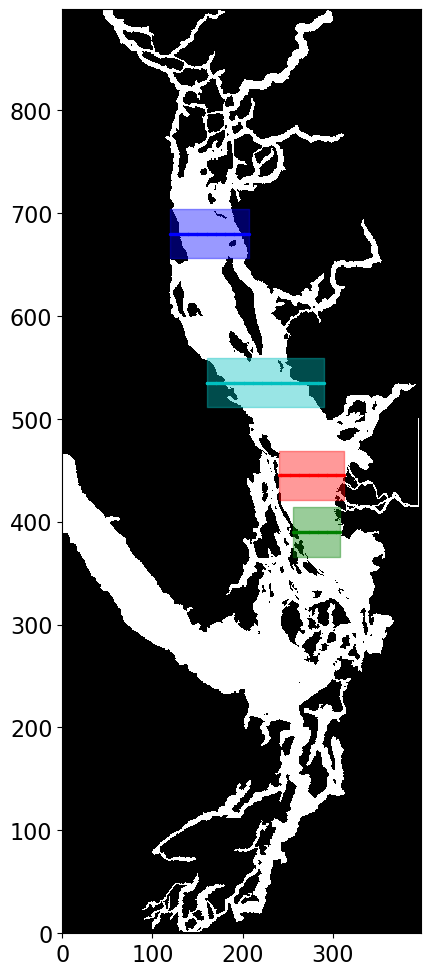

In [89]:
line_s = np.arange(240, s_x + 10)
line_y = [s_y] * len(line_s)
#
line_c = np.arange(160, s_x - 12)
line_yc = [s_y + 90] * len(line_c)
#
line_n = np.arange(120, s_x - 95)
line_yn = [s_y + 235] * len(line_n)
#
line_ss = np.arange(256, s_x + 6)
line_yss = [s_y - 55] * len(line_ss)
#
colors_0 = [(0, 0, 0, 1),  # Black for land
          (0, 0, 0, 0)]  # Transparent for water
cmap = ListedColormap(colors_0)
#
dd = 12
idx = 450
fig, ax = plt.subplots(figsize = (15,12))
ax.pcolormesh(mask['tmask'][0,0], cmap = cmap)
ax.set_aspect(1.14)
ax.scatter(line_s, line_y, s = 2, c = 'r')
ax.fill_between(line_s, y1 = s_y-dd*2, y2 = s_y+dd*2, color = 'r',  alpha = .4)
#
ax.scatter(line_c, line_yc, s = 2, c = 'c')
ax.fill_between(line_c, y1 = s_y + 90-dd*2, y2 = s_y + 90+dd*2, color = 'c', alpha = .4)
#
ax.scatter(line_n, line_yn, s = 2, c = 'b')
ax.fill_between(line_n, y1 = s_y + 235-dd*2, y2 = s_y + 235+dd*2, color = 'b', alpha = .4)
#
#
ax.scatter(line_ss, line_yss, s = 2,  c = 'g')
ax.fill_between(line_ss, y1 = s_y - 55-dd*2, y2 = s_y - 55+dd*2, color = 'g', alpha = .4)


In [6]:
from scipy.spatial import cKDTree

def get_grid_indices_vectorized(part_lons, part_lats, mask):
    #
    grid_lats = mask.nav_lat.values.flatten()
    grid_lons = mask.nav_lon.values.flatten()
    tree = cKDTree(np.c_[grid_lats, grid_lons])
    
    #
    _, indices = tree.query(np.c_[part_lats, part_lons])
    
    #
    shape_x = mask.nav_lon.shape[1]
    return indices // shape_x, indices % shape_x

In [7]:
# 1. Distance Calculator aligned to a specific Reference X-index
def get_aligned_transect_dist(y_idx, x_start, x_end, ref_x, mask):
    lons = mask['nav_lon'].values[y_idx, x_start:x_end]
    lats = mask['nav_lat'].values[y_idx, x_start:x_end]
    
    # Calculate absolute cumulative distance from x_start
    dists = [0]
    for i in range(1, len(lons)):
        d_lat = lats[i] - lats[0]
        d_lon = (lons[i] - lons[0]) * np.cos(np.radians(lats[0]))
        distance_km = np.sqrt(d_lat**2 + d_lon**2) * 111.32
        dists.append(distance_km)
    
    dists = np.array(dists)
    
    # Shift the array so that ref_x is exactly 0 km
    ref_idx = int(ref_x) - x_start
    return dists - dists[ref_idx]

# 2. Flexible Slice Extractor
def extract_transect(data, mask, grid_3d, y_idx, x_start, x_end, dd=12, num_z_bins=40):
    tmask = mask['tmask'][0, 0].values
    y_start, y_end = max(0, y_idx - dd), min(grid_3d.shape[1], y_idx + dd + 1)
    
    num_x_steps = x_end - x_start
    transect_matrix = np.zeros((num_z_bins, num_x_steps))
    
    for idx_x, x_val in enumerate(range(x_start, x_end)):
        local_mask = tmask[y_start:y_end, x_val]
        for k in range(num_z_bins):
            box_counts = grid_3d[k, y_start:y_end, x_val]
            transect_matrix[k, idx_x] = np.sum(box_counts[local_mask == 1])
            
    return transect_matrix

In [101]:
file_year1 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_1.nc'
file_year2 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_2.nc'
file_year3 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_3.nc'
file_year4 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_4.nc'
file_year5 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_5.nc'
file_year6 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_6.nc'
file_year7 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_7.nc'
file_year8 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_8.nc'
file_year9 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_9.nc'
file_year10 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_10.nc'
file_year11 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_11.nc'
file_year12 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_12.nc'
file_year13 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_13.nc'
#
vars_to_keep = ['trajectory', 'obs', 'lon', 'lat', 'z', 'time', 'status']
#
data = xr.open_dataset(file_year1, drop_variables=[v for v in xr.open_dataset(file_year1).variables if v not in vars_to_keep])

In [96]:
# 1. Extract and filter valid water particles
status = data['status'].values.flatten()
idx_wat = (status > 0) & (status < 4)

p_lons = data['lon'].values.flatten()[idx_wat]
p_lats = data['lat'].values.flatten()[idx_wat]
p_depths = data['z'].values.flatten()[idx_wat]

# 2. Convert Lat/Lon to Grid Indices using your KDTree function
print("Converting particle coordinates to grid indices...")
p_y, p_x = get_grid_indices_vectorized(p_lons, p_lats, mask)

# 3. Define the bins for the 3D Histogram
num_z_bins = 40
z_bins = np.linspace(0, 450, num_z_bins + 1)          # The vertical layers
y_bins = np.arange(0, mask.nav_lat.shape[0] + 1)      # The Y-axis (Latitude grid)
x_bins = np.arange(0, mask.nav_lat.shape[1] + 1)      # The X-axis (Longitude grid)

# 4. Generate the master 3D grid
print("Populating the 3D grid with particles...")
grid_3d, _ = np.histogramdd(
    (p_depths, p_y, p_x), 
    bins=(z_bins, y_bins, x_bins)
)

# Now you have z_bins, and you can calculate the centers for plotting
z_centers = (z_bins[:-1] + z_bins[1:]) / 2

Converting particle coordinates to grid indices...
Populating the 3D grid with particles...


In [97]:
# Setup the dictionary for your 3 locations
transects = {
    'North':  {'y': s_y + 235, 'x_start': 120, 'x_end': int(s_x) - 95},
    'Central':  {'y': s_y + 90, 'x_start': 160, 'x_end': int(s_x) - 12},
    'Source':   {'y': s_y,      'x_start': 240, 'x_end': int(s_x + 10)},
    'South':  {'y': s_y - 55, 'x_start': 256, 'x_end': int(s_x + 6)}
}

results = {}

for name, params in transects.items():
    y, xs, xe = params['y'], params['x_start'], params['x_end']
    
    # Calculate aligned distance (0 km at source)
    dist_km = get_aligned_transect_dist(y, xs, xe, ref_x=xs, mask=mask)
    
    # Extract the data using the grid_3d we just built
    data_matrix = extract_transect(data, mask, grid_3d, y, xs, xe, dd=24)
    
    # Extract bathymetry
    bathy_raw = bathy['Bathymetry'][y, xs:xe].values
    #bathy_smooth = np.convolve(bathy_raw, np.ones(5)/5, mode='same')
    #bathy_smooth[0:2], bathy_smooth[-2:] = bathy_raw[0:2], bathy_raw[-2:]
    
    results[name] = {'dist': dist_km, 'data': data_matrix, 'bathy': bathy_raw}

# Proceed to plotting...

/tmp/ipykernel_2245057/2488158532.py:68: UserWarning: Log scale: values of z <= 0 have been masked
  cntr = ax_data.contourf(res['dist'], z_centers, res['data'],


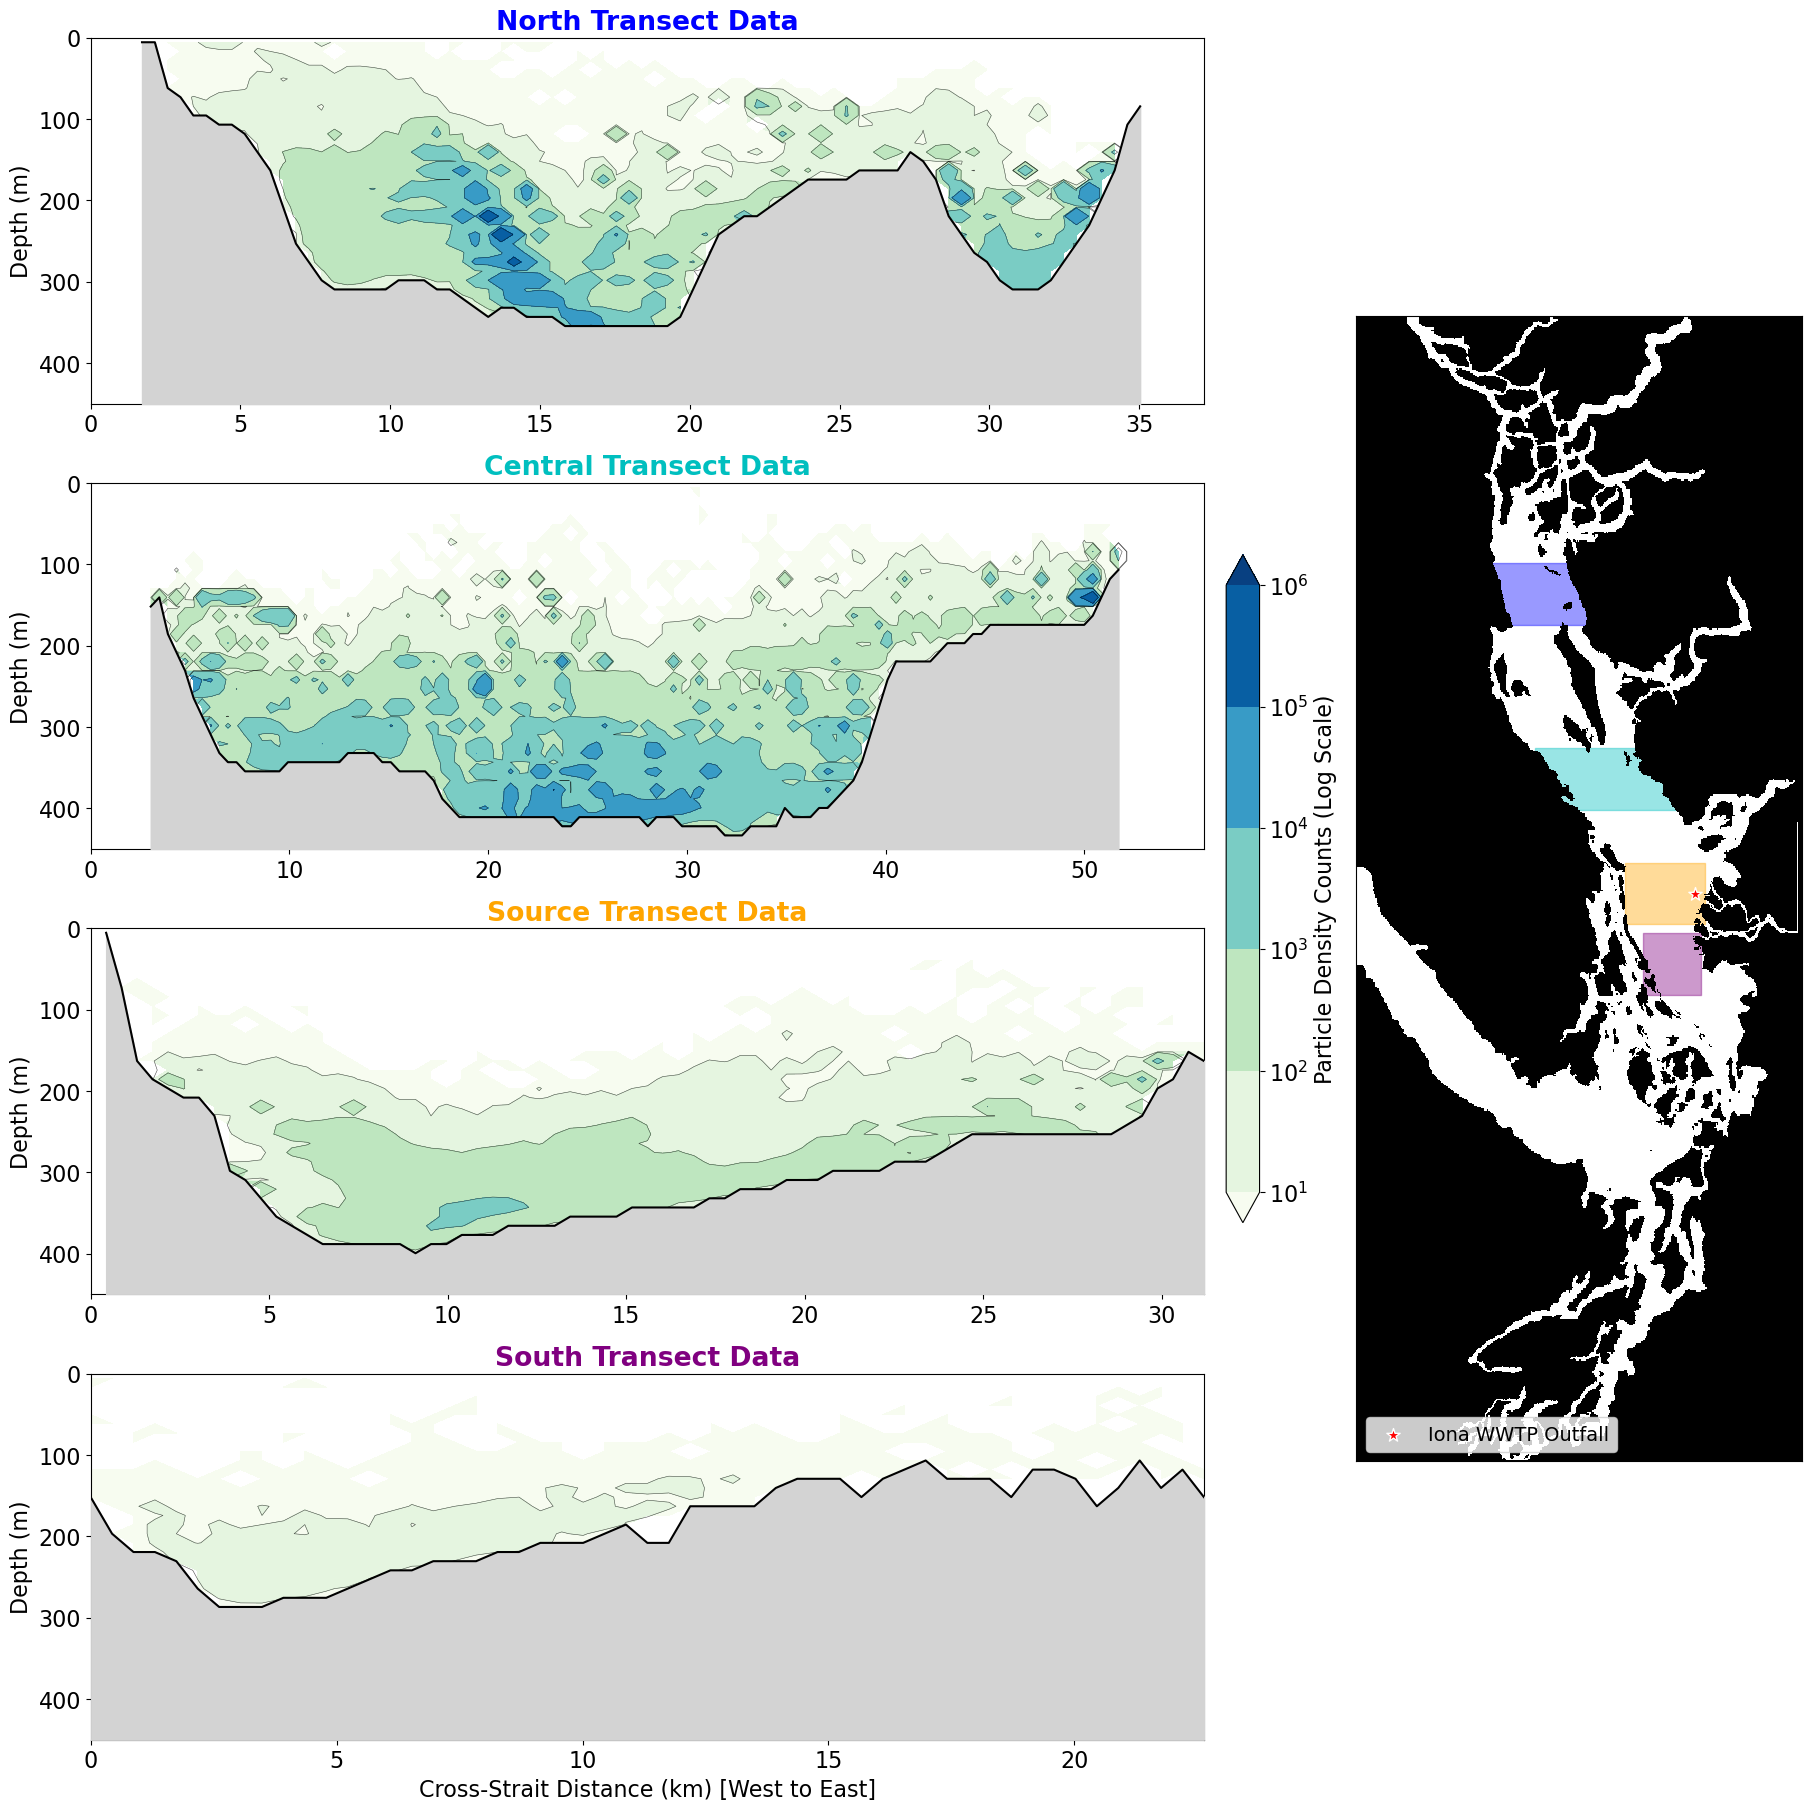

In [ ]:
plt.rcParams.update({'font.size': 16})

# 1. Define Map Colors
colors_0 = [(0, 0, 0, 1), (0, 0, 0, 0)]  # Black for land, Transparent for water
cmap_mask = ListedColormap(colors_0)

# 2. Define Transect Parameters
dd = 24
transects = {
    'North': {
        'y': s_y + 235, 
        'x_start': 120, 
        'x_end': int(s_x  - 95),
        'color': 'b'
    },
    'Central': {
        'y': s_y + 90, 
        'x_start': 160, 
        'x_end': int(s_x  - 12),
        'color': 'c'
    },    
    'Source': {
        'y': s_y,      
        'x_start': 240, 
        'x_end': int(s_x + 10),
        'color': 'orange'
    },
    'South': {
        'y': s_y - 55, 
        'x_start': 256, 
        'x_end': int(s_x+6),
        'color': 'purple'
    }
}

# 3. Setup the Figure with GridSpec
fig = plt.figure(figsize=(18, 18), layout='constrained')
gs = fig.add_gridspec(4, 2, width_ratios=[2.5, 1])

# Initialize the single map on the right column (spanning all 4 rows)
ax_map = fig.add_subplot(gs[:, 1])

# Plot static map elements once
ax_map.pcolormesh(mask['tmask'][0,0], cmap=cmap_mask, zorder=3)
ax_map.set_aspect(1.14)
ax_map.scatter(s_x, s_y, color='red', marker='*', edgecolor='w', s=100, zorder=5, label='Iona WWTP Outfall')
ax_map.set_xticks([])
ax_map.set_yticks([])
#
levels = [10, 100, 1000, 10000, 100000, 1000000]
plot_order = ['North', 'Central', 'Source', 'South']

# List to store the left-column axes for attaching the colorbar later
ax_data_list = []

for i, name in enumerate(plot_order):
    # Initialize the specific row in the left column
    ax_data = fig.add_subplot(gs[i, 0])
    ax_data_list.append(ax_data)
    
    res = results[name]
    params = transects[name]
    t_color = params['color']
    
    # ==========================================
    # COLUMN 1: THE CROSS-STRAIT DATA PLOT
    # ==========================================
    cntr = ax_data.contourf(res['dist'], z_centers, res['data'], 
                            levels=levels, cmap='GnBu', 
                            norm=LogNorm(vmin=levels[0], vmax=levels[-1]), extend='both')
    
    ax_data.contour(res['dist'], z_centers, res['data'], 
                    levels=levels, colors='black', linewidths=0.4, alpha=0.7)
    
    # Seafloor
    artificial_bathy = np.full_like(res['dist'], np.nan, dtype=float)
    
    for j in range(len(res['dist'])):
        valid_idx = np.where(~np.isnan(res['data'][:, j]) & (res['data'][:, j] > 0))[0]
        
        if len(valid_idx) > 0:
            artificial_bathy[j] = z_centers[valid_idx[-1]]

    ax_data.fill_between(res['dist'], artificial_bathy, 450, color='lightgrey', zorder=3)
    ax_data.plot(res['dist'], artificial_bathy, color='black', linewidth=1.5, zorder=4)

    # Formatting
    ax_data.invert_yaxis()
    ax_data.set_ylim(450, 0)
    ax_data.set_ylabel("Depth (m)")
    ax_data.set_title(f"{name} Transect Data", fontweight='bold', color=t_color)

    #
    line_x = np.arange(params['x_start'], params['x_end'])
    
    ax_map.fill_between(line_x, y1=params['y']-dd, y2=params['y']+dd, color=t_color, alpha=0.4, zorder=2)
    

    if i == 3:
        ax_data.set_xlabel("Cross-Strait Distance (km) [West to East]")

# Add map legend once at the end
ax_map.legend(loc='lower left', fontsize=14)

#
cbar = fig.colorbar(cntr, ax=ax_data_list, orientation='vertical', fraction=0.03, pad=0.02, ticks=levels)
cbar.set_label('Particle Density Counts (Log Scale)')
cbar.ax.set_yticklabels([f'$10^{{{int(np.log10(l))}}}$' for l in levels])

plt.show()

# Animation

In [102]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LogNorm
from matplotlib.animation import FuncAnimation

# 1. Store all files in a list
file_list = [
    file_year1, file_year2, file_year3, file_year4, file_year5,
    file_year6, file_year7, file_year8, file_year9, file_year10,
    file_year11, file_year12, file_year13
]

vars_to_keep = ['trajectory', 'obs', 'lon', 'lat', 'z', 'time', 'status']

# Grid setup (Assumes `mask`, `bathy`, `s_y`, `s_x`, and custom functions are already loaded)
num_z_bins = 40
z_bins = np.linspace(0, 450, num_z_bins + 1)
y_bins = np.arange(0, mask.nav_lat.shape[0] + 1)
x_bins = np.arange(0, mask.nav_lat.shape[1] + 1)
z_centers = (z_bins[:-1] + z_bins[1:]) / 2

transects = {
    'North':  {'y': s_y + 235, 'x_start': 120, 'x_end': int(s_x) - 95,  'color': 'b'},
    'Central':{'y': s_y + 90,  'x_start': 160, 'x_end': int(s_x) - 12,  'color': 'c'},
    'Source': {'y': s_y,       'x_start': 240, 'x_end': int(s_x + 10),  'color': 'orange'},
    'South':  {'y': s_y - 55,  'x_start': 256, 'x_end': int(s_x + 6),   'color': 'purple'}
}

# 2. Loop through all years and pre-compute results
all_years_results = []

print("Pre-computing data for all years...")
for year_idx, filepath in enumerate(file_list):
    print(f"Processing Year {year_idx + 1}...")
    
    # Open dataset and drop unnecessary variables
    ds = xr.open_dataset(filepath, drop_variables=[v for v in xr.open_dataset(filepath).variables if v not in vars_to_keep])
    
    # Extract valid water particles
    status = ds['status'].values.flatten()
    idx_wat = (status > 0) & (status < 4)
    p_lons = ds['lon'].values.flatten()[idx_wat]
    p_lats = ds['lat'].values.flatten()[idx_wat]
    p_depths = ds['z'].values.flatten()[idx_wat]
    
    # Convert coordinates
    p_y, p_x = get_grid_indices_vectorized(p_lons, p_lats, mask)
    
    # Generate 3D grid
    grid_3d, _ = np.histogramdd((p_depths, p_y, p_x), bins=(z_bins, y_bins, x_bins))
    
    # Extract transects for this specific year
    year_results = {}
    for name, params in transects.items():
        y, xs, xe = params['y'], params['x_start'], params['x_end']
        dist_km = get_aligned_transect_dist(y, xs, xe, ref_x=xs, mask=mask)
        data_matrix = extract_transect(ds, mask, grid_3d, y, xs, xe, dd=24)
        
        # Calculate artificial bathymetry to avoid recomputing during animation
        artificial_bathy = np.full_like(dist_km, np.nan, dtype=float)
        for j in range(len(dist_km)):
            valid_idx = np.where(~np.isnan(data_matrix[:, j]) & (data_matrix[:, j] > 0))[0]
            if len(valid_idx) > 0:
                artificial_bathy[j] = z_centers[valid_idx[-1]]
                
        year_results[name] = {'dist': dist_km, 'data': data_matrix, 'bathy': artificial_bathy}
        
    all_years_results.append(year_results)
    ds.close()

print("Pre-computation complete!")

Pre-computing data for all years...
Processing Year 1...
Processing Year 2...
Processing Year 3...
Processing Year 4...
Processing Year 5...
Processing Year 6...
Processing Year 7...
Processing Year 8...
Processing Year 9...
Processing Year 10...
Processing Year 11...
Processing Year 12...
Processing Year 13...
Pre-computation complete!


Generating animation...


/tmp/ipykernel_2245057/632499106.py:60: UserWarning: Log scale: values of z <= 0 have been masked
  ax.contourf(res['dist'], z_centers, res['data'],


Animation saved successfully!


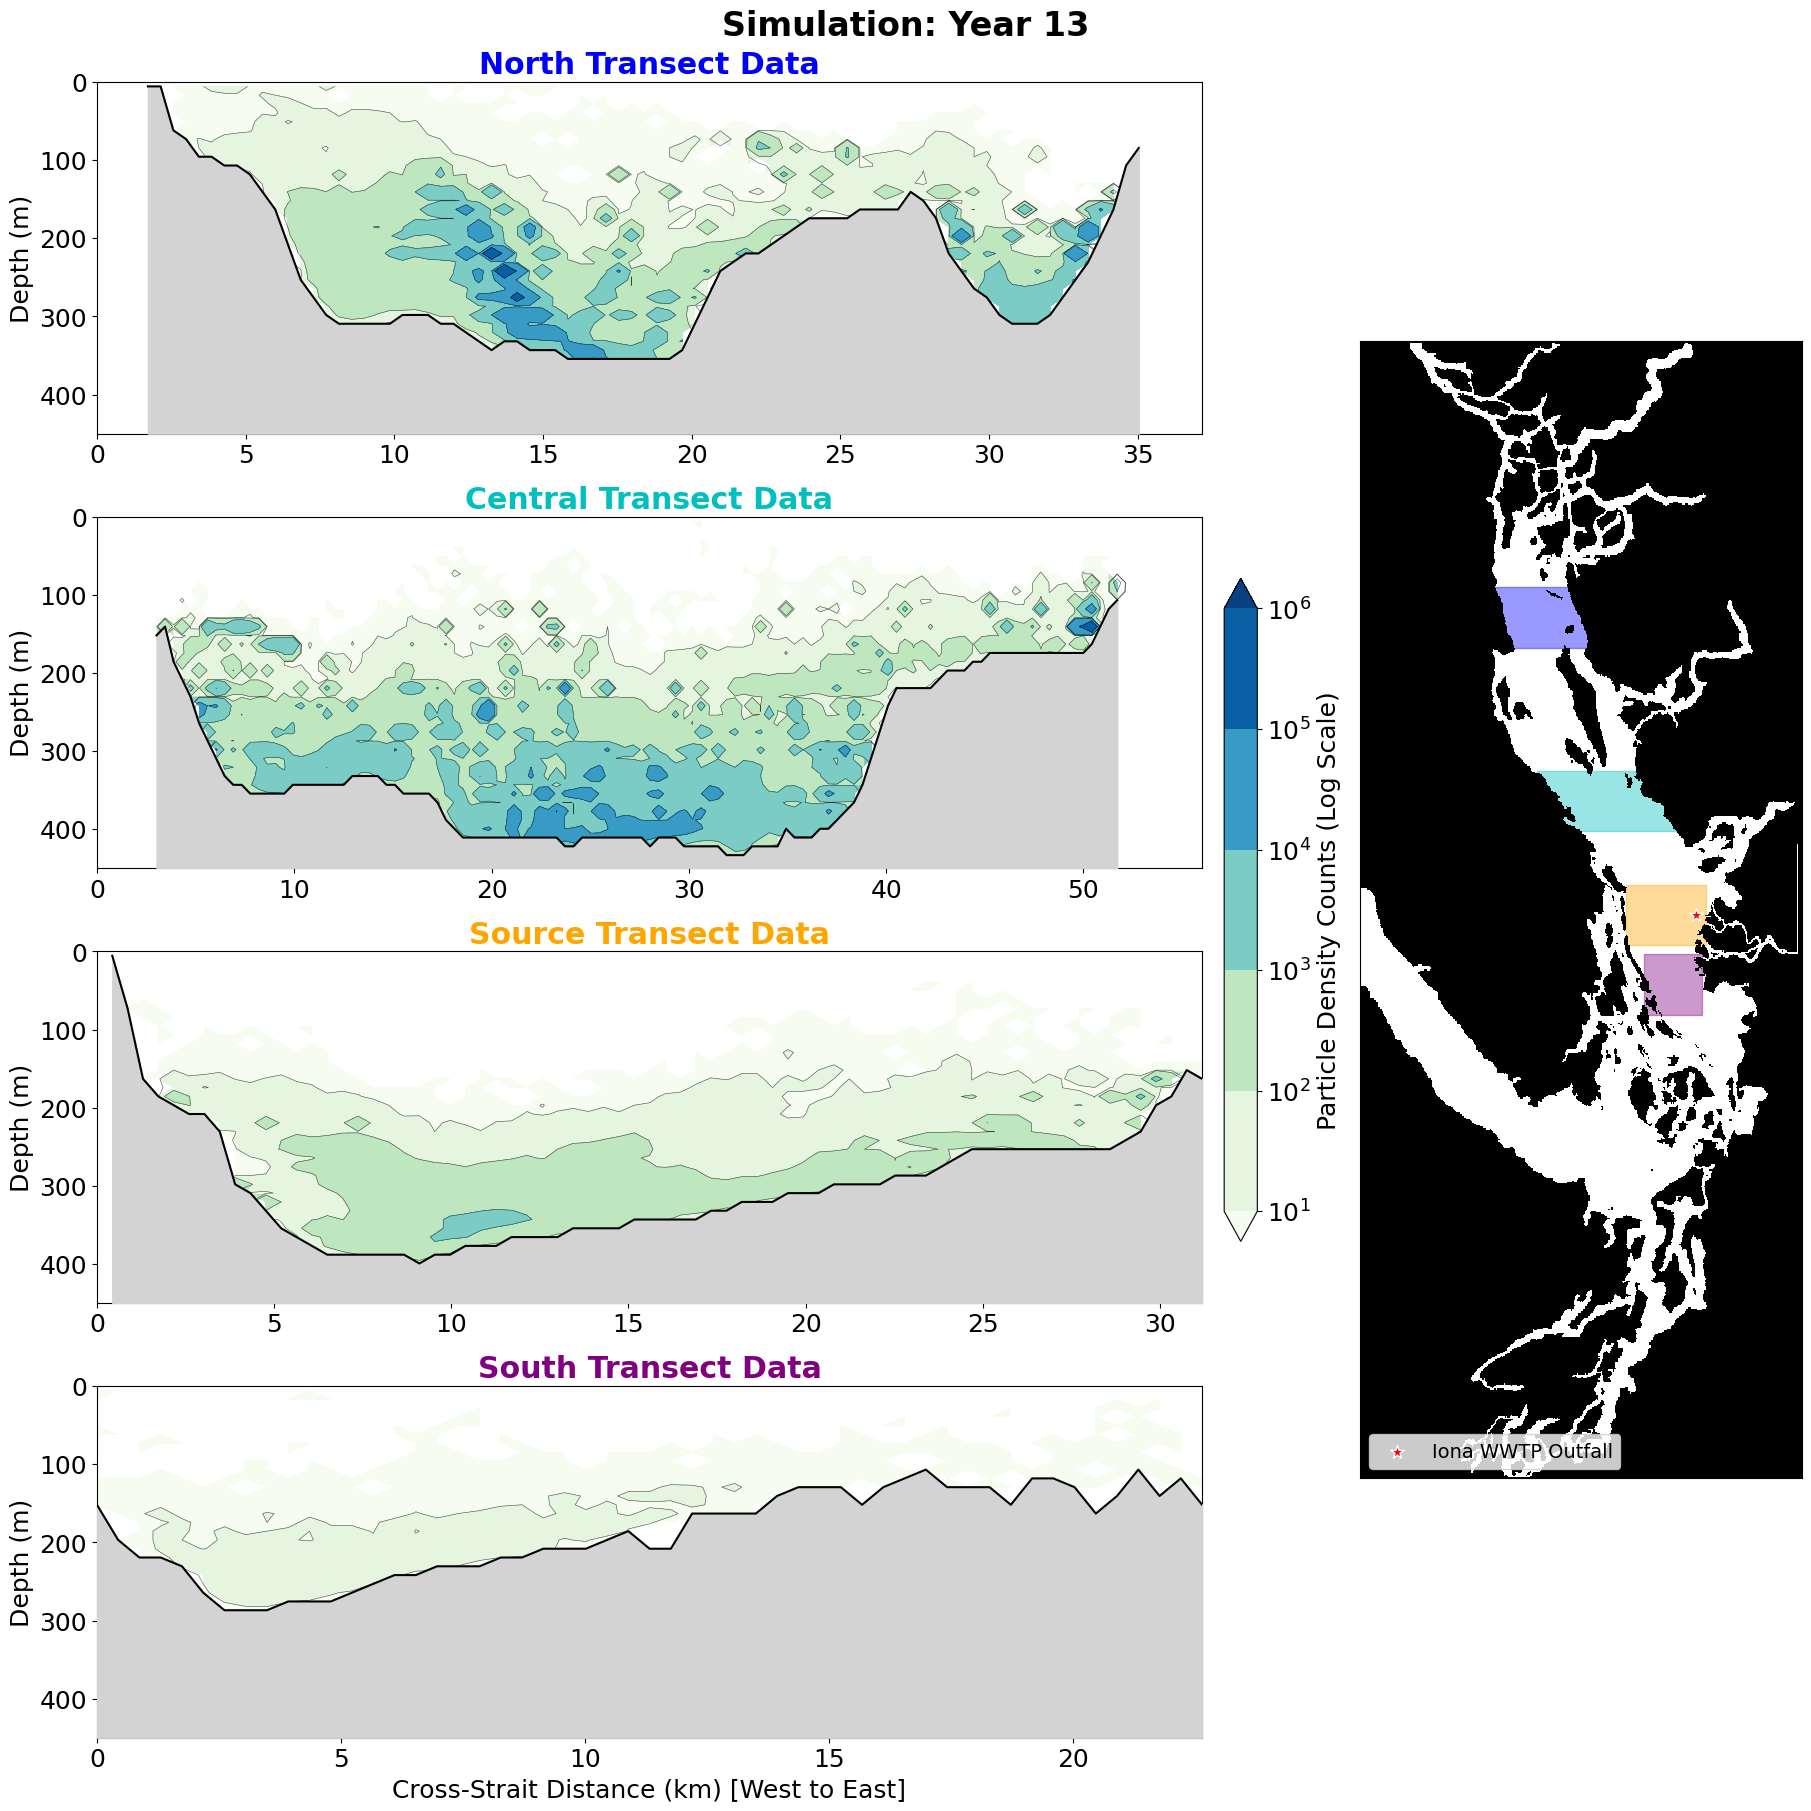

In [103]:
plt.rcParams.update({'font.size': 18})

# Define Map Colors and parameters
colors_0 = [(0, 0, 0, 1), (0, 0, 0, 0)]
cmap_mask = ListedColormap(colors_0)
levels = [10, 100, 1000, 10000, 100000, 1000000]
plot_order = ['North', 'Central', 'Source', 'South']

# Setup Figure
fig = plt.figure(figsize=(18, 18), layout='constrained')
gs = fig.add_gridspec(4, 2, width_ratios=[2.5, 1])

# Initialize the static map
ax_map = fig.add_subplot(gs[:, 1])
ax_map.pcolormesh(mask['tmask'][0,0], cmap=cmap_mask, zorder=3)
ax_map.set_aspect(1.14)
ax_map.scatter(s_x, s_y, color='red', marker='*', edgecolor='w', s=100, zorder=5, label='Iona WWTP Outfall')
ax_map.set_xticks([])
ax_map.set_yticks([])

# Draw transect lines on the static map
dd = 24
for name in plot_order:
    params = transects[name]
    line_x = np.arange(params['x_start'], params['x_end'])
    ax_map.fill_between(line_x, y1=params['y']-dd, y2=params['y']+dd, color=params['color'], alpha=0.4, zorder=2)
ax_map.legend(loc='lower left', fontsize=14)

# Create the left-column axes
ax_data_list = [fig.add_subplot(gs[i, 0]) for i in range(4)]

# Create a dummy contour to generate the colorbar (prevents colorbar from vanishing during ax.clear)
dummy_z = np.zeros((len(z_centers), len(all_years_results[0]['Source']['dist'])))
dummy_z[:] = 10  # Min level
cntr = ax_data_list[0].contourf(all_years_results[0]['Source']['dist'], z_centers, dummy_z,
                                levels=levels, cmap='GnBu', norm=LogNorm(vmin=levels[0], vmax=levels[-1]), extend='both')

cbar = fig.colorbar(cntr, ax=ax_data_list, orientation='vertical', fraction=0.03, pad=0.02, ticks=levels)
cbar.set_label('Particle Density Counts (Log Scale)')
cbar.ax.set_yticklabels([f'$10^{{{int(np.log10(l))}}}$' for l in levels])

# Title text object to update the year
title_text = fig.suptitle("Simulation: Year 1", fontsize=24, fontweight='bold')

# The Animation Update Function
def update(frame):
    # 'frame' goes from 0 to 12
    year_data = all_years_results[frame]
    title_text.set_text(f"Simulation: Year {frame + 1}")
    
    for i, name in enumerate(plot_order):
        ax = ax_data_list[i]
        ax.clear()  # Clear previous contours
        
        res = year_data[name]
        params = transects[name]
        t_color = params['color']
        
        # Redraw contours
        ax.contourf(res['dist'], z_centers, res['data'], 
                    levels=levels, cmap='GnBu', 
                    norm=LogNorm(vmin=levels[0], vmax=levels[-1]), extend='both')
        
        ax.contour(res['dist'], z_centers, res['data'], 
                   levels=levels, colors='black', linewidths=0.4, alpha=0.7)
        
        # Redraw seafloor
        artificial_bathy = res['bathy']
        ax.fill_between(res['dist'], artificial_bathy, 450, color='lightgrey', zorder=3)
        ax.plot(res['dist'], artificial_bathy, color='black', linewidth=1.5, zorder=4)

        # Restore Formatting
        ax.invert_yaxis()
        ax.set_ylim(450, 0)
        ax.set_ylabel("Depth (m)")
        ax.set_title(f"{name} Transect Data", fontweight='bold', color=t_color)

        if i == 3:
            ax.set_xlabel("Cross-Strait Distance (km) [West to East]")
            
    return ax_data_list

# Generate the animation
print("Generating animation...")
ani = FuncAnimation(fig, update, frames=len(file_list), interval=1000, blit=False)

# Save or show the animation
# Note: You may need ffmpeg installed to save as mp4
ani.save('cross_transect_simulation_13years.mp4', writer='ffmpeg', fps=1, dpi=150)
print("Animation saved successfully!")

plt.show() # Uncomment if you are in an interactive environment (e.g. Jupyter)

In [105]:
bathy['Bathymetry']

<xarray.DataArray 'Bathymetry' (y: 898, x: 398)> Size: 3MB
[357404 values with dtype=float64]
Dimensions without coordinates: y, x
Attributes:
    units:      metres
    long_name:  sea_floor_depth

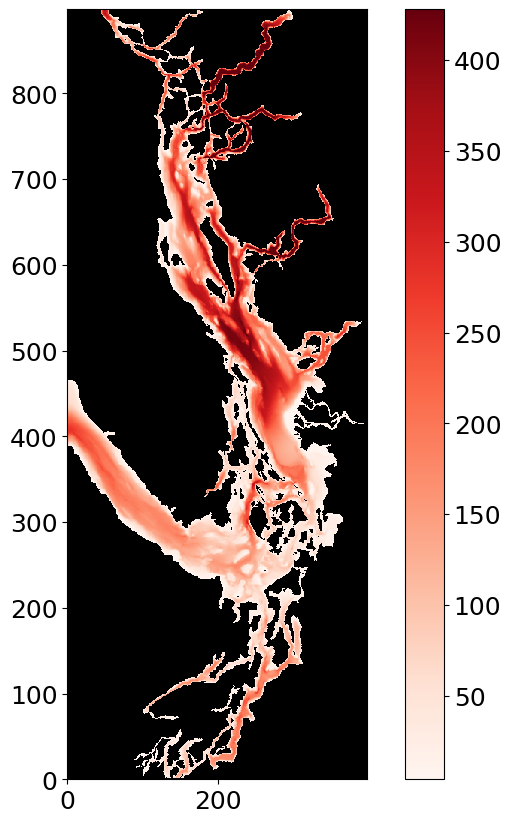

In [117]:
fig, ax = plt.subplots(figsize = (10, 10))
bathymetry = ax.pcolormesh(bathy['Bathymetry'], cmap = 'Reds')
ax.pcolormesh(mask['tmask'][0][0], cmap = cmap_mask)
ax.set_aspect(1.14)
plt.colorbar(bathymetry)